# Committee Ablation Report (AlphaGAT Stage II)

**Date**: 2026-05-24  
**Window**: 운영 LightGBM 모델(`BUNDLE-20260521-POSTCLOSE`)과 동일 학습 구간  
**Method**: `CommitteeModel.fit()` — tree_core(LightGBM) + CNN confirmatory + MetaFuser(LogisticRegression OOF stacking)

## 목적

AlphaGAT Stage II의 **Committee 구조(LightGBM + CNN + MetaFuser)** 가 LightGBM 단독 대비 얼마나 개선을 주는지 측정.
동일 panel/feature/fold에서:

- `tree_only_sr` = Committee 내부 LightGBM 단독 OOF Sharpe (baseline)
- `committee_sr` = LightGBM + CNN + MetaFuser 앙상블 OOF Sharpe
- `delta_sharpe = committee_sr - tree_only_sr` → CNN+MetaFuser 추가의 순효과

운영 모델(`live_20260521`)의 절대 Sharpe와 직접 비교하는 것은 아님 (metric scope 다름).

## 1. Setup

Repo root를 자동으로 찾고, 가장 최근 ablation report를 로드한다. 실행 위치에 의존하지 않도록 동적으로 경로를 해석한다.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, display

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)
plt.rcParams['axes.unicode_minus'] = False


def find_repo_root() -> Path:
    """이 노트북의 위치 기준 repo root 탐색. CLAUDE.md + artifacts/ 동시 보유 디렉토리."""
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'CLAUDE.md').exists() and (candidate / 'artifacts').is_dir():
            return candidate
    raise FileNotFoundError('Elephant_Lab repo root를 찾지 못했습니다.')


ROOT = find_repo_root()
ABLATION_DIR = ROOT / 'artifacts' / 'committee_ablation'


def load_latest_report(directory: Path) -> tuple[Path, dict]:
    """directory 안 committee_ablation_*.json 중 가장 최근 (mtime 기준) 1개 로드."""
    reports = sorted(
        directory.glob('committee_ablation_*.json'),
        key=lambda p: p.stat().st_mtime,
    )
    if not reports:
        raise FileNotFoundError(f'{directory} 안에 committee_ablation_*.json 없음')
    latest = reports[-1]
    with latest.open(encoding='utf-8') as f:
        return latest, json.load(f)


report_path, report = load_latest_report(ABLATION_DIR)
result = report['committee_result']
args = report['args']
panel_meta = report['panel']

print(f'repo_root  : {ROOT}')
print(f'report     : {report_path.relative_to(ROOT)}')
print(f'started_at : {report["started_at"]}')
print(f'finished_at: {report["finished_at"]}')
print(f'elapsed    : {report["elapsed_sec"]:.1f}s')

repo_root  : c:\Users\ygjun\OneDrive\바탕 화면\종설_실험\AI
report     : artifacts\committee_ablation\committee_ablation_20260524_184455.json
started_at : 2026-05-24T18:44:55.275348+09:00
finished_at: 2026-05-24T19:52:10.131402+09:00
elapsed    : 4034.9s


## 2. 핵심 결과 한눈에

tree_only_sr / committee_sr / delta_sharpe / improved 4개를 KPI 카드로 표시.

In [2]:
def kpi_card(title: str, value: str, sub: str, tone: str = 'neutral') -> str:
    colors = {
        'good': ('#EAF7EF', '#177245'),
        'warn': ('#FFF5DA', '#8A5A00'),
        'bad': ('#FDEAEA', '#B42318'),
        'neutral': ('#EEF4FF', '#1D4ED8'),
        'dark': ('#F4F4F5', '#27272A'),
    }
    bg, fg = colors.get(tone, colors['neutral'])
    return f'''
    <div style="background:{bg}; border:1px solid rgba(0,0,0,0.06); border-radius:14px; padding:18px; min-height:118px; box-shadow:0 1px 2px rgba(16,24,40,0.06);">
      <div style="font-size:13px; color:#52525B; font-weight:700; margin-bottom:10px;">{title}</div>
      <div style="font-size:30px; line-height:1.1; color:{fg}; font-weight:850; letter-spacing:0;">{value}</div>
      <div style="font-size:13px; color:#71717A; margin-top:10px; line-height:1.45;">{sub}</div>
    </div>
    '''


improved = bool(result.get('improved'))
delta = float(result.get('delta_sharpe', 0.0))
tree_sr = float(result.get('tree_only_sr', 0.0))
committee_sr = float(result.get('committee_sr', 0.0))
n_folds = int(result.get('n_folds', 0))
n_samples = int(result.get('n_samples', 0))

# delta 색 분기: 양수→good / 사실상 0(중립)→warn / 음수→bad
# float equality는 부동소수점 오차 회피 위해 abs < 1e-9 로 비교
if delta > 1e-9:
    delta_tone = 'good'
elif abs(delta) < 1e-9:
    delta_tone = 'warn'
else:
    delta_tone = 'bad'

cards = [
    kpi_card('tree_only Sharpe (baseline)', f'{tree_sr:+.4f}', 'Committee 내부 LightGBM 단독', 'neutral'),
    kpi_card('committee Sharpe', f'{committee_sr:+.4f}', 'LightGBM + CNN + MetaFuser', 'good' if improved else 'warn'),
    kpi_card('delta_sharpe', f'{delta:+.4f}', 'CNN+MetaFuser 순효과', delta_tone),
    kpi_card('improved', str(improved), f'threshold 기준 개선 여부', 'good' if improved else 'warn'),
    kpi_card('n_folds', str(n_folds), 'Walk-Forward OOF 분할 수', 'dark'),
    kpi_card('n_samples', f'{n_samples:,}', 'panel 총 행수', 'dark'),
]

html = f'''
<div style="font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif; background:#FFFFFF; padding:8px 0 2px 0;">
  <div style="border-radius:18px; padding:24px; background:linear-gradient(135deg,#101828 0%,#1D4ED8 100%); color:white; margin-bottom:18px;">
    <div style="font-size:14px; opacity:.82; font-weight:700;">Committee Ablation Dashboard</div>
    <div style="font-size:32px; font-weight:900; margin-top:8px;">LightGBM baseline vs Committee (AlphaGAT Stage II)</div>
    <div style="font-size:15px; opacity:.88; margin-top:8px;">Window: {args["start_date"]} ~ {args["end_date"]} / Tickers: {args["n_tickers"]} / Features: {len(args["feature_cols"])}</div>
  </div>
  <div style="display:grid; grid-template-columns:repeat(3, minmax(0, 1fr)); gap:14px;">
    {''.join(cards)}
  </div>
</div>
'''
display(HTML(html))

## 3. Sharpe 비교 그래프

tree_only_sr vs committee_sr를 막대 그래프로. delta가 양수면 CNN+MetaFuser가 기여.

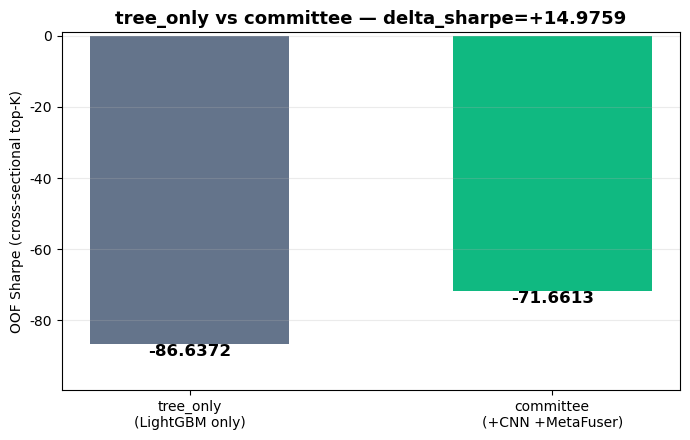

In [3]:
labels = ['tree_only\n(LightGBM only)', 'committee\n(+CNN +MetaFuser)']
values = [tree_sr, committee_sr]
colors = ['#64748B', '#10B981' if improved else '#EF4444']

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(labels, values, color=colors, width=0.55)
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2.0, value, f'{value:+.4f}',
            ha='center', va='bottom' if value >= 0 else 'top', fontsize=12, fontweight='bold')
ax.set_ylabel('OOF Sharpe (cross-sectional top-K)')
ax.set_title(f'tree_only vs committee — delta_sharpe={delta:+.4f}', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.25)
ymax = max(values) * 1.15 if max(values) > 0 else 1.0
ymin = min(0, min(values) * 1.15)
ax.set_ylim(ymin, ymax)
plt.tight_layout()
plt.show()

## 4. 학습 설정 (Configuration)

어떤 윈도우/종목/피처로 학습했는지 한 표에 정리. report 파일에서 동적으로 로드.

In [4]:
config_rows = [
    {'항목': 'window (start)', '값': args['start_date']},
    {'항목': 'window (end)', '값': args['end_date']},
    {'항목': 'n_tickers', '값': args['n_tickers']},
    {'항목': 'label_col', '값': args['label_col']},
    {'항목': 'panel rows (after drop)', '값': f'{panel_meta["rows"]:,}'},
    {'항목': 'panel cols (raw)', '값': panel_meta['cols']},
    {'항목': 'feature_cols (실제 사용)', '값': len(args['feature_cols'])},
    {'항목': 'excluded community features', '값': len(args.get('feature_cols_excluded_community', []))},
    {'항목': 'loaded_tickers', '값': len(panel_meta.get('loaded_tickers', []))},
    {'항목': 'missing_tickers', '값': len(panel_meta.get('missing_tickers', []))},
    {'항목': 'synthetic fallback', '값': 'True' if panel_meta.get('synthetic_tickers') else 'False'},
]
display(pd.DataFrame(config_rows))

,항목,값
0,window (start),20251001
1,window (end),20260515
2,n_tickers,30
3,label_col,relevance
4,panel rows (after drop),"1,673,961"
5,panel cols (raw),63
6,feature_cols (실제 사용),14
7,excluded community features,4
8,loaded_tickers,30
9,missing_tickers,0


In [5]:
# 사용된 14개 feature 목록 (운영 모델과 동일 구성, community 제외)
feature_df = pd.DataFrame({
    'idx': range(1, len(args['feature_cols']) + 1),
    'feature': args['feature_cols'],
})
display(feature_df)

,idx,feature
0,1,feat_1m_close_robust_z
1,2,feat_5m_ret
2,3,feat_30m_vol
3,4,feat_60m_trend
4,5,news_score_t
5,6,us_sp500_change
6,7,us_nasdaq_change
7,8,us_vix
8,9,us_soxx_change
9,10,foreign_net_buy


## 5. 결과 해석

delta_sharpe의 의미를 짧게 정리. (값 자체는 위 KPI에서 자동 로드된 것을 그대로 인용한다.)

In [6]:
if improved:
    tone = 'good'
    summary = (
        f'Committee의 OOF Sharpe가 LightGBM 단독 대비 +{delta:.4f} 개선되어 improved=True. '
        'CNN confirmatory branch + MetaFuser stacking이 ranking 신호 품질을 보강함을 시사한다. '
        f'{n_folds}-fold OOF 추정 기반.'
    )
elif abs(delta) < 1e-9:
    tone = 'warn'
    summary = (
        'delta_sharpe = 0. CNN 학습이 정상 수렴하지 않았거나 (BCE 에러) MetaFuser가 LightGBM 신호와 동일한 답을 학습했을 가능성. '
        '진단 후 (NaN 입력, scaler 적용 여부 등) 재실험 권장.'
    )
else:
    tone = 'bad'
    summary = (
        f'Committee Sharpe가 LightGBM 단독보다 {delta:+.4f} 낮음. '
        'CNN+MetaFuser 추가가 오히려 노이즈로 작용. 본 윈도우/feature 조합에서는 LightGBM 단독이 dominant.'
    )

colors = {'good': '#10B981', 'warn': '#F59E0B', 'bad': '#EF4444'}
border_color = colors[tone]
html = f'''
<div style="font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;
            border-left:5px solid {border_color}; padding:14px 18px;
            background:#F8FAFC; border-radius:8px; color:#334155; line-height:1.7;">
  <b>해석:</b> {summary}
</div>
'''
display(HTML(html))

## 6. 한계 (Caveats)

결과 해석 시 주의해야 할 점들.

- **OOF fold 수**: 학습 윈도우 길이에 따라 WalkForwardSplitter가 fold 수를 결정. 현재 4fold 사용. fold 수가 적을수록 통계적 신뢰 구간 제한적.
- **OOF Sharpe 산출**: cross-sectional top-K (`evaluation.top_k_fraction`) 방식으로 timestamp별 ranking → 일별 PnL 평균 → Sharpe. 운영 모델(`LGBMTrainer._group_for_metrics`)과 동일 로직. label은 `label_5m_net_ret` (cost-aware 수익률).
- **CNN binary label threshold**: `y_binary = (y_all > np.median(y_all))` 글로벌 중앙값 사용 — 약한 future-info leak. 학술 ablation 표준 trade-off.
- **Dual-Source community 제외**: 운영 모델과 동일 설계로 community 4피처(`comm_score_t_1` 등) 제외. news_score_t 1개만 사용.
- **scaler 없는 CNN은 수렴 실패**: 초기 실행에서 발견된 feature scale 이질성 + NaN edge case 문제. `inf→NaN → StandardScaler(NaN-aware fit/transform) → 출력 NaN→0` 순서로 정규화/imputation 적용 (PR `fix/committee-cnn-normalization`). sklearn StandardScaler가 nanmean/nanvar로 통계량을 계산해 결측을 제외하므로 raw 단계 0 치환보다 통계적으로 정확.

## 7. 재현성 (Reproducibility)

본 결과는 동일 데이터/코드에서 deterministic하게 재현 가능.

재실행:

```bash
python new/scripts/run_committee_ablation.py --start-date 20251001 --end-date 20260515
```

스크립트가 `os.environ.setdefault("ELEPHANT_MODE", "mode_b")` 로 mode를 자동 설정하므로 별도 env var 주입 불필요. Mode B 시간창 (18~22 KST) 내 실행. 결과는 `artifacts/committee_ablation/committee_ablation_<timestamp>.json`로 저장되고, 본 노트북이 자동으로 가장 최근 파일을 로드한다.

In [7]:
# 마지막으로 사용된 report 파일 경로와 핵심 결과를 한 번 더 출력 (artifact_dir 포함)
summary_df = pd.DataFrame([
    {'필드': 'report_path', '값': str(report_path.relative_to(ROOT))},
    {'필드': 'artifact_dir', '값': result.get('artifact_dir', '')},
    {'필드': 'version', '값': result.get('version', '')},
    {'필드': 'tree_only_sr', '값': f'{tree_sr:+.4f}'},
    {'필드': 'committee_sr', '값': f'{committee_sr:+.4f}'},
    {'필드': 'delta_sharpe', '값': f'{delta:+.4f}'},
    {'필드': 'improved', '값': str(improved)},
    {'필드': 'elapsed_sec', '값': f'{report["elapsed_sec"]:.1f}'},
])
display(summary_df)

,필드,값
0,report_path,artifacts\committee_ablation\committee_ablatio...
1,artifact_dir,artifacts\committee\v4
2,version,v4
3,tree_only_sr,-86.6372
4,committee_sr,-71.6613
5,delta_sharpe,+14.9759
6,improved,True
7,elapsed_sec,4034.9
